In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')


In [4]:
df = pd.read_csv('../data/cleaned_accident_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (1000, 26)


,accident_id,date,week_day,state,severity,weather,location,time,light_condition,vehicle_type,...,casualty_age,casualty_sex,social_class,casualty_type,pedestrian_or_passenger,year,month,month_name,hour,time_of_day
0,AID0001,2022-11-20,T,WB,Minor,Storm,Loc91,1958,Daylight,Car,...,33,M,Upper,Pedestrian,Pedestrian,2022,11,November,19,Evening
1,AID0002,2023-12-09,T,TR,Severe,Fog,Loc184,2245,Daylight,Car,...,9,M,Middle,Pedestrian,Pedestrian,2023,12,December,22,Night
2,AID0003,2022-11-12,W,HP,Moderate,Fog,Loc77,250,Twilight,Car,...,45,F,Working,Car Passenger,Pedestrian,2022,11,November,2,Night
3,AID0004,2023-02-13,T,CG,Severe,Clear,Loc78,545,Night,Motorcycle,...,59,M,Working,Motorcyclist,Pedestrian,2023,2,February,5,Night
4,AID0005,2022-11-25,S,TR,Moderate,Storm,Loc57,2146,Twilight,Car,...,30,F,Working,Cyclist,Pedestrian,2022,11,November,21,Night


In [5]:
print("Severity values:")
print(df['severity'].value_counts())
print()
print("Severity data type:", df['severity'].dtype)

Severity values:
severity
Moderate    336
Minor       335
Severe      329
Name: count, dtype: int64

Severity data type: object


In [7]:
# Select useful columns for ML
features = ['state', 'weather', 'vehicle_type', 'driver_sex', 
            'driver_age', 'car_age', 'hour', 'week_day',
            'light_condition', 'casualty_type', 'engine_size']

target = 'severity'

# Create X and y
X = df[features]
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print()
print("Target classes:", y.unique())

Features shape: (1000, 11)
Target shape: (1000,)

Target classes: ['Minor' 'Severe' 'Moderate']


In [11]:

le = LabelEncoder()

X_encoded = X.copy()

categorical_cols = ['state', 'weather', 'vehicle_type', 
                    'driver_sex', 'week_day', 
                    'light_condition', 'casualty_type']

for col in categorical_cols:
    X_encoded[col] = le.fit_transform(X_encoded[col])

# Encode target
y_encoded = le.fit_transform(y)

print( "Encoding done!")
print(X_encoded.head())

Encoding done!
   state  weather  vehicle_type  driver_sex  driver_age  car_age  hour  \
0     27        4             1           1          48       20    19   
1     24        1             1           0          21       10    22   
2      8        1             1           1          62        6     2   
3      4        0             2           1          26       18     5   
4     24        4             1           1          20        2    21   

   week_day  light_condition  casualty_type  engine_size  
0         3                0              3         1089  
1         3                0              3         2653  
2         4                2              0         2997  
3         3                1              2         2079  
4         2                2              1         2279  


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, 
    test_size=0.2, 
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (800, 11)
Testing size: (200, 11)


In [13]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
print(" Random Forest trained!")
print(f"Random Forest Accuracy: {round(rf_accuracy * 100, 2)}%")

 Random Forest trained!
Random Forest Accuracy: 31.0%


In [15]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
print(" XGBoost trained!")
print(f"XGBoost Accuracy: {round(xgb_accuracy * 100, 2)}%")

 XGBoost trained!
XGBoost Accuracy: 37.0%


In [16]:
print("=" * 40)
print("       MODEL COMPARISON")
print("=" * 40)
print(f"Random Forest : {round(rf_accuracy * 100, 2)}%")
print(f"XGBoost       : {round(xgb_accuracy * 100, 2)}%")
print("=" * 40)

if rf_accuracy > xgb_accuracy:
    print(" Best Model: Random Forest")
    best_model = rf_model
    best_pred = rf_pred
else:
    print(" Best Model: XGBoost")
    best_model = xgb_model
    best_pred = xgb_pred

       MODEL COMPARISON
Random Forest : 31.0%
XGBoost       : 37.0%
 Best Model: XGBoost


In [17]:
print("Classification Report:")
print(classification_report(y_test, best_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.40      0.38        68
           1       0.41      0.39      0.40        67
           2       0.34      0.32      0.33        65

    accuracy                           0.37       200
   macro avg       0.37      0.37      0.37       200
weighted avg       0.37      0.37      0.37       200



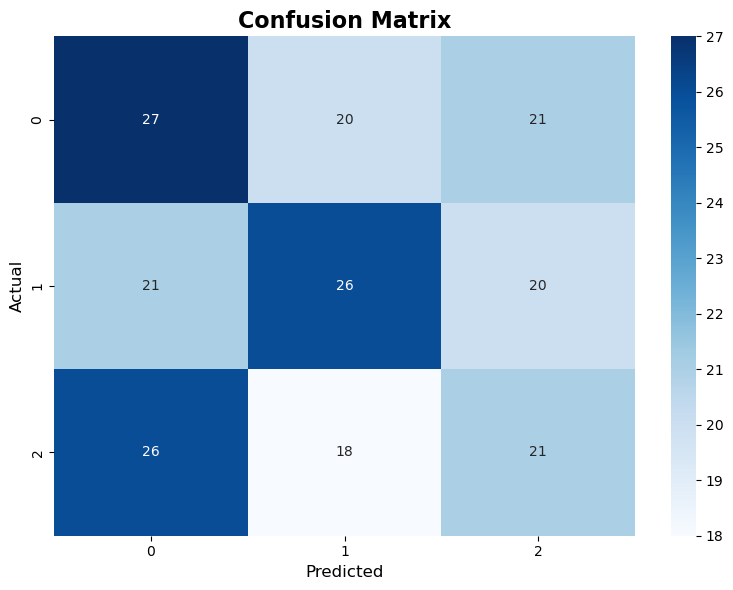

In [18]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()

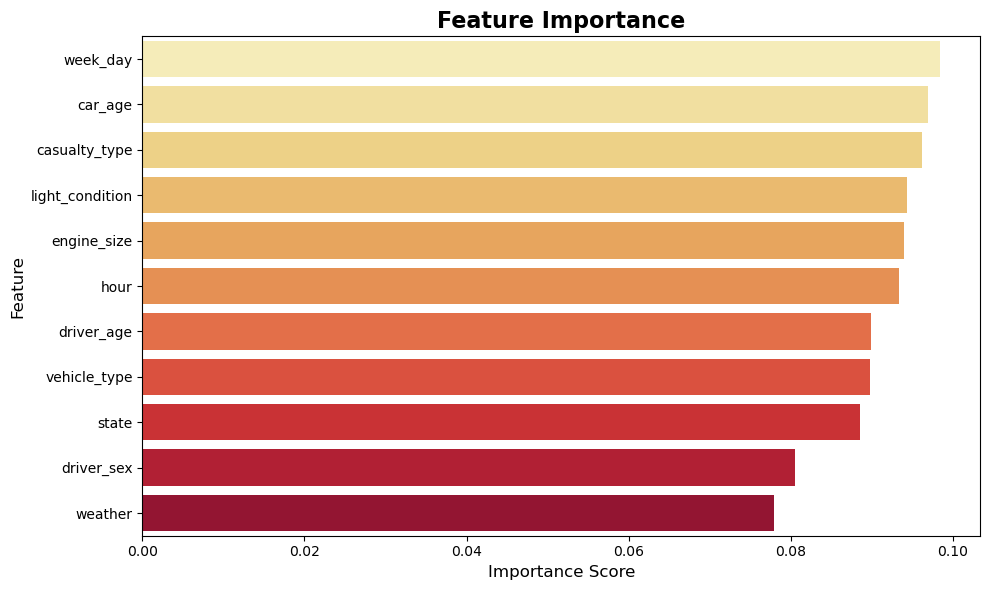

            feature  importance
7          week_day    0.098430
5           car_age    0.096930
9     casualty_type    0.096192
8   light_condition    0.094354
10      engine_size    0.093985
6              hour    0.093353
4        driver_age    0.089927
2      vehicle_type    0.089781
0             state    0.088524
3        driver_sex    0.080573
1           weather    0.077951


In [19]:
plt.figure(figsize=(10, 6))
importance_df = pd.DataFrame({
    'feature': features,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

sns.barplot(x='importance', y='feature', 
            data=importance_df, palette='YlOrRd')
plt.title('Feature Importance', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()
print(importance_df)

In [20]:
import pickle

with open('../data/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Best model saved as best_model.pkl!")

Best model saved as best_model.pkl!
